# Recreation of Section 5. Model Validation from *Model design for networks of heterogeneous Hodgkin–Huxley neurons* by Giannari et al.
Source: https://www.sciencedirect.com/science/article/pii/S0925231222005148#t0010

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

In [2]:
NEURON_TYPE_PARAMS = {
    # Initial HH Model parameters taken from Table 2:
    # Capacitor
    "C_M": {"FS": 0.5, "RSA": 1.0, "IB": 1.0},

    # Conductances
    "g_bar_K": {"FS": 10.0, "RSA": 6.0, "IB": 5.0},
    "g_bar_M": {"FS": 0.0, "RSA": 0.075, "IB": 0.03},
    "g_bar_Ca": {"FS": 0.0, "RSA": 0.0, "IB": 0.2},
    "g_bar_Na": {"FS": 56.0, "RSA": 56.0, "IB": 50.0},
    "g_L": {"FS": 0.015, "RSA": 0.0205, "IB": 0.01},

    "tau_max": {"FS": 1.0, "RSA": 608.0, "IB": 608.0},

    # Resting potentials
    "V_K": {"FS": -90.0, "RSA": -90.0, "IB": -90.0},
    "V_Ca": {"FS": 0.0, "RSA": 0.0, "IB": 120.0},
    "V_Na": {"FS": 50.0, "RSA": 56.0, "IB": 50.0},
    "V_L": {"FS": -70.0, "RSA": -70.3, "IB": -70.0},
    "V_T": {"FS": -56.2, "RSA": -56.2, "IB": -56.2},     # threshold adjustment for FS neurons

    # Synapse parameters taken from Table 3:
    "tau_r": {"FS": 0.5, "RSA": 0.5, "IB": 0.5},        # rise time
    "tau_d": {"FS": 8.0, "RSA": 8.0, "IB": 8.0},        # decay time
    "V_syn": {"FS": -80.0, "RSA": 20.0, "IB": 20.0},    # reversal potential of the synapse
    "V_0": {"FS": -20.0, "RSA": -20.0, "IB": -20.0},    # reversal potential
}

def generate_simulation_params(param_dict, neuron_types):
    return np.array([[param_dict[nt]] for nt in neuron_types], dtype=float)

Generate alpha and beta rate terms for each gate

In [3]:
def get_rates(gate_type: str, V, V_T):
    # Gates used in all neuron types
    if gate_type == "n":
        common_term = V - V_T - 15
        alpha = (common_term * -0.032) / (np.exp(-common_term / 5) - 1)
        beta = 0.5 * np.exp(-(V - V_T - 10) / 40)

    elif gate_type == "m":
        common_term = V - V_T - 13
        alpha = (common_term * -0.32) / (np.exp(-common_term / 4) - 1)
        beta = 0.28 * (np.exp(-(V - V_T - 40) / 5)) - 1
    
    elif gate_type == "h":
        alpha = 0.128 * np.exp(-(V - V_T - 17) / 18)
        beta = 4 / (np.exp(-(V - V_T - 40) / 5) + 1)
    
    # Additional gates for IB Neuron type
    elif gate_type == "q":
        common_term = -27 - V
        alpha = 0.0055 * common_term / (np.exp(common_term / 3.8) - 1)
        beta = 0.0065 / (np.exp((-15 - V) / 28) + 1)
    
    elif gate_type == "s":
        alpha = 0.000457 * np.exp((-13 - V) / 50)
        beta = 0.94 * np.exp((-75 - V) / 17)

    return alpha, beta

# Steady state for the additional gate requried for the RSA neuron type
def get_p_inf(V):
    p_inf = 1 / (np.exp(-(V + 35) / 10) + 1)
    return p_inf

Heterogenous Hodgkin-Huxley Model that uses vectorized network equation to describe multiple neuron interactions

In [4]:
class HeterogeneousHH():
    def __init__(
            self,
            N,
            C_M,
            g_bar_K,
            g_bar_M,
            g_bar_Ca,
            g_bar_Na,
            g_L,
            V_K,
            V_Ca,
            V_Na,
            V_L,
            V_T,
            V_syn,
            tau_max,
            tau_r,
            tau_d,
            V_0,
            L_el,   # Laplacian of electrical synapses
            A_ch,   # Adjacency matrix of chemical synapses
            V_init,
            n_init,
            m_init,
            h_init,
            p_init,
            q_init,
            s_init,
            r_init,
    ):
        # Injected current
        self.injected_current = 0.0

        # neuron/model parameters
        self.N = N
        self.C_M = C_M
        self.g_bar_K = g_bar_K
        self.g_bar_M = g_bar_M
        self.g_bar_Ca = g_bar_Ca
        self.g_bar_Na = g_bar_Na
        self.g_L = g_L
        self.V_K = V_K
        self.V_Ca = V_Ca
        self.V_Na = V_Na
        self.V_L = V_L
        self.V_T = V_T
        self.V_syn = V_syn
        self.tau_max = tau_max
        self.tau_r = tau_r
        self.tau_d = tau_d
        self.V_0 = V_0
        self.L_el = L_el
        self.A_ch = A_ch

        # Save initial values
        self.V_init = V_init.copy()
        self.n_init = n_init.copy()
        self.m_init = m_init.copy()
        self.h_init = h_init.copy()
        self.p_init = p_init.copy()
        self.q_init = q_init.copy()
        self.s_init = s_init.copy()
        self.r_init = r_init.copy()


        # Start with initial values
        self.V = V_init.copy()
        self.n = n_init.copy()
        self.m = m_init.copy()
        self.h = h_init.copy()
        self.p = p_init.copy()
        self.q = q_init.copy()
        self.s = s_init.copy()
        self.r = r_init.copy()

        self.V_history = [V_init]
        self.n_history = [n_init]
        self.m_history = [m_init]
        self.h_history = [h_init]
        self.p_history = [p_init]
        self.q_history = [q_init]
        self.s_history = [s_init]
        self.r_history = [r_init]

    # Gates used in all neuron types
    def dndt(self):
        alpha, beta = get_rates("n", self.V, self.V_T)
        return alpha * (1 - self.n) - beta * self.n

    def dmdt(self):
        alpha, beta = get_rates("m", self.V, self.V_T)
        return alpha * (1 - self.m) - beta * self.m

    def dhdt(self):
        alpha, beta = get_rates("h", self.V, self.V_T)
        return alpha * (1 - self.h) - beta * self.h

    # Additional gate for the RSA neuron type
    def dpdt(self):
        p_inf = get_p_inf(self.V)
        tau_p = self.tau_max / (
            3.3 * np.exp((self.V + 35) / 20) + np.exp(-(self.V + 35) / 20)
        )

        return (p_inf - self.p) / tau_p

    # Additional gates for IB Neuron type
    def dqdt(self):
        alpha, beta = get_rates("q", self.V, self.V_T)
        return alpha * (1 - self.q) - beta * self.q

    def dsdt(self):
        alpha, beta = get_rates("s", self.V, self.V_T)
        return alpha * (1 - self.s) - beta * self.s

    # Fraction of receptors bound to neurotransmitters
    def drdt(self):
        return (
            ((1 / self.tau_r) - (1 / self.tau_d))
            * ((1 - self.r) / (1 + np.exp(-self.V + self.V_0)))
            - (self.r / self.tau_d)
        )
    
    # Combined Feedback of both electrical and chemical synapses
    def u(self):
        u_el = -self.L_el @ self.V

        V_hat = self.V_syn - self.V
        # u_ch = self.A_ch @ (np.eye(N) * np.kron(np.ones((1, N)), self.r) * V_hat)
        u_ch = self.A_ch @ (self.r * V_hat)
        return u_el + u_ch
    
    def dVdt(self):
        return (np.ones((self.N, 1)) / self.C_M) * (
            self.injected_current
            - self.g_bar_K * self.n**4 * (self.V - self.V_K)
            - self.g_bar_M * self.p * (self.V - self.V_K)
            - self.g_bar_Ca * self.q**2 * self.s * (self.V - self.V_Ca)
            - self.g_bar_Na * self.m**3 * self.h * (self.V - self.V_Na)
            - self.g_L * (self.V - self.V_L)
            + self.u()
        )

    def step(self, dt, injected_current):
        self.injected_current = injected_current

        # compute all derivatives using the current state
        dV = self.dVdt()
        dn = self.dndt()
        dm = self.dmdt()
        dh = self.dhdt()
        dp = self.dpdt()
        dq = self.dqdt()
        ds = self.dsdt()
        dr = self.drdt()

        # Euler update
        self.V = self.V + dV * dt
        self.n = self.n + dn * dt
        self.m = self.m + dm * dt
        self.h = self.h + dh * dt
        self.p = self.p + dp * dt
        self.q = self.q + dq * dt
        self.s = self.s + ds * dt
        self.r = self.r + dr * dt

        # clip voltage to prevent exp overflow
        self.V = np.clip(self.V, -100, 100)

        # clip gating variables to valid range
        self.n = np.clip(self.n, 0.0, 1.0)
        self.m = np.clip(self.m, 0.0, 1.0)
        self.h = np.clip(self.h, 0.0, 1.0)
        self.p = np.clip(self.p, 0.0, 1.0)
        self.q = np.clip(self.q, 0.0, 1.0)
        self.s = np.clip(self.s, 0.0, 1.0)
        self.r = np.clip(self.r, 0.0, 1.0)

        # remove NaNs
        self.V = np.nan_to_num(self.V)
        self.n = np.nan_to_num(self.n)
        self.m = np.nan_to_num(self.m)
        self.h = np.nan_to_num(self.h)
        self.p = np.nan_to_num(self.p)
        self.q = np.nan_to_num(self.q)
        self.s = np.nan_to_num(self.s)
        self.r = np.nan_to_num(self.r)

        self.V_history.append(self.V.copy())
        self.n_history.append(self.n.copy())
        self.m_history.append(self.m.copy())
        self.h_history.append(self.h.copy())
        self.p_history.append(self.p.copy())
        self.q_history.append(self.q.copy())
        self.s_history.append(self.s.copy())
        self.r_history.append(self.r.copy())

        # Reset injected current to 0 for next step
        self.injected_current = 0.0
    
    def _reset_internal_state(self):
        self.V = self.V_init.copy()
        self.n = self.n_init.copy()
        self.m = self.m_init.copy()
        self.h = self.h_init.copy()
        self.p = self.p_init.copy()
        self.q = self.q_init.copy()
        self.s = self.s_init.copy()
        self.r = self.r_init.copy()

        self.V_history = [self.V_init]
        self.n_history = [self.n_init]
        self.m_history = [self.m_init]
        self.h_history = [self.h_init]
        self.p_history = [self.p_init]
        self.q_history = [self.q_init]
        self.s_history = [self.s_init]
        self.r_history = [self.r_init]
    
    def run_simulation(self, dt, injected_current):
        self._reset_internal_state()

        # go through each time step and update
        for k in tqdm(range(injected_current.shape[1] - 1)):
            self.step(dt, injected_current[:, [k]])

Methods for visualizing results

In [5]:
def get_neuron_type_and_index(i, N_FS, N_RSA):
    if i < N_FS:
        return "FS", i
    elif i < N_FS + N_RSA:
        return "RSA", i - N_FS
    else:
        return "IB", i - (N_FS + N_RSA)

def create_plot_materials(i, N, N_FS, N_RSA, axes, colors, times, V_hist, I_ext, all_handles, all_labels, remove_constant_currents=False):
    neuron_type, neuron_type_idx = get_neuron_type_and_index(i, N_FS, N_RSA)
    color = colors[i % len(colors)]

    # Voltage plot
    line, = axes[i].plot(
        times,
        V_hist[:, i, 0],
        color=color,
        label=f"{neuron_type} Neuron {neuron_type_idx + 1}"
    )

    if not remove_constant_currents:
        # Current plot
        axes[N + i].plot(
            times,
            I_ext[i],
            color=color
        )

    all_handles.append(line)
    all_labels.append(f"{neuron_type} Neuron {neuron_type_idx + 1}")


# Model Validation
## 1. Uncoupled neurons with distinct firing patterns for FS, RSA and IB, all receiving external current
Generate the parameters for the vector that is ordered by FS, RSA and IB: <br>
$ V = [V_1, ..., V_{N_{FS}}, V_{N_{FS} + 1}, ..., V_{N_{FS} + N_{RSA}}, V_{N_{FS} + N_{RSA} + 1}, ..., V_{N}]^T$

In [6]:
N_FS = 1                    # number of FS neurons
N_RSA = 1                   # number of RSA neurons
N_IB = 1                    # number of IB neurons
N = N_FS + N_RSA +  N_IB    # number of neurons in the network

# SEED for random injection current choices
SEED = 341

neuron_types = (
    ["FS"] * N_FS +
    ["RSA"] * N_RSA +
    ["IB"] * N_IB
)

C_M     = generate_simulation_params(NEURON_TYPE_PARAMS["C_M"], neuron_types)
g_bar_K = generate_simulation_params(NEURON_TYPE_PARAMS["g_bar_K"], neuron_types)
g_bar_M = generate_simulation_params(NEURON_TYPE_PARAMS["g_bar_M"], neuron_types)
g_bar_Ca= generate_simulation_params(NEURON_TYPE_PARAMS["g_bar_Ca"], neuron_types)
g_bar_Na= generate_simulation_params(NEURON_TYPE_PARAMS["g_bar_Na"], neuron_types)
g_L     = generate_simulation_params(NEURON_TYPE_PARAMS["g_L"], neuron_types)

tau_max = generate_simulation_params(NEURON_TYPE_PARAMS["tau_max"], neuron_types)

V_K     = generate_simulation_params(NEURON_TYPE_PARAMS["V_K"], neuron_types)
V_Ca    = generate_simulation_params(NEURON_TYPE_PARAMS["V_Ca"], neuron_types)
V_Na    = generate_simulation_params(NEURON_TYPE_PARAMS["V_Na"], neuron_types)
V_L     = generate_simulation_params(NEURON_TYPE_PARAMS["V_L"], neuron_types)
V_T     = generate_simulation_params(NEURON_TYPE_PARAMS["V_T"], neuron_types)

tau_r   = generate_simulation_params(NEURON_TYPE_PARAMS["tau_r"], neuron_types)
tau_d   = generate_simulation_params(NEURON_TYPE_PARAMS["tau_d"], neuron_types)
V_syn   = generate_simulation_params(NEURON_TYPE_PARAMS["V_syn"], neuron_types)
V_0     = generate_simulation_params(NEURON_TYPE_PARAMS["V_0"], neuron_types)

Connections between Neurons (Electrical and Chemical Synapses)

In [7]:
# Adjacency matrices describing the electrical synapses
A_el = np.zeros((N, N))
degrees_el = np.sum(A_el, axis=1)
D_el = np.diag(degrees_el)
L_el = D_el - A_el

# Chemical synapses allow for self-loops
A_ch = np.zeros((N, N))
degrees_ch = np.sum(A_ch, axis=1)
D_ch = np.diag(degrees_ch)
L_ch = D_ch - A_ch

# Selection vector to determine which neurons receive external current
S = np.array([[1], [1], [1]])

# Time parameters
dt = 0.1                # Time step size
total_time = 2500.0     # Total Time to run the experiment for (ms)
times = np.arange(0.0, total_time + dt, dt)
cur_start_time = 500.0
cur_stop_time = 2000.0

# Injected Current
def injection_current(seed, times, start, stop, max_amplitude, block_time):
    rng = np.random.default_rng(seed)
    I_inj = np.zeros_like(times, dtype=float)

    current_time = start
    while current_time < stop:
        amp = rng.uniform(0.0, max_amplitude)
        mask = (times >= current_time) & (times < min(current_time + block_time, stop))
        I_inj[mask] = amp
        current_time += block_time

    return I_inj

block_time = 50.0
I_inj = injection_current(seed=SEED, times=times, start=cur_start_time, stop=cur_stop_time, max_amplitude=1, block_time=block_time)

# External Current
I_ext = S * I_inj

### Set up the model

In [8]:
V_init = V_L.copy()

# Steady state initial concentrations for the gates
alpha_n, beta_n = get_rates("n", V_init, V_T)
n_init =  alpha_n / (alpha_n + beta_n)

alpha_m, beta_m = get_rates("m", V_init, V_T)
m_init = alpha_m / (alpha_m + beta_m)

alpha_h, beta_h = get_rates("h", V_init, V_T)
h_init = alpha_h / (alpha_h + beta_h)

p_init = get_p_inf(V_init)

alpha_q, beta_q = get_rates("q", V_init, V_T)
q_init = alpha_q / (alpha_q + beta_q)

alpha_s, beta_s = get_rates("s", V_init, V_T)
s_init = alpha_s / (alpha_s + beta_s)

r_init = np.zeros((N, 1))

uncoupled_model = HeterogeneousHH(
    N, C_M, g_bar_K, g_bar_M, g_bar_Ca, g_bar_Na, g_L,
    V_K, V_Ca, V_Na, V_L, V_T, V_syn,
    tau_max, tau_r, tau_d, V_0,
    L_el, A_ch,
    V_init, n_init, m_init, h_init,
    p_init, q_init, s_init, r_init,
)

### Run the simulation

In [9]:
uncoupled_model.run_simulation(dt, I_ext)

  0%|          | 0/25000 [00:00<?, ?it/s]

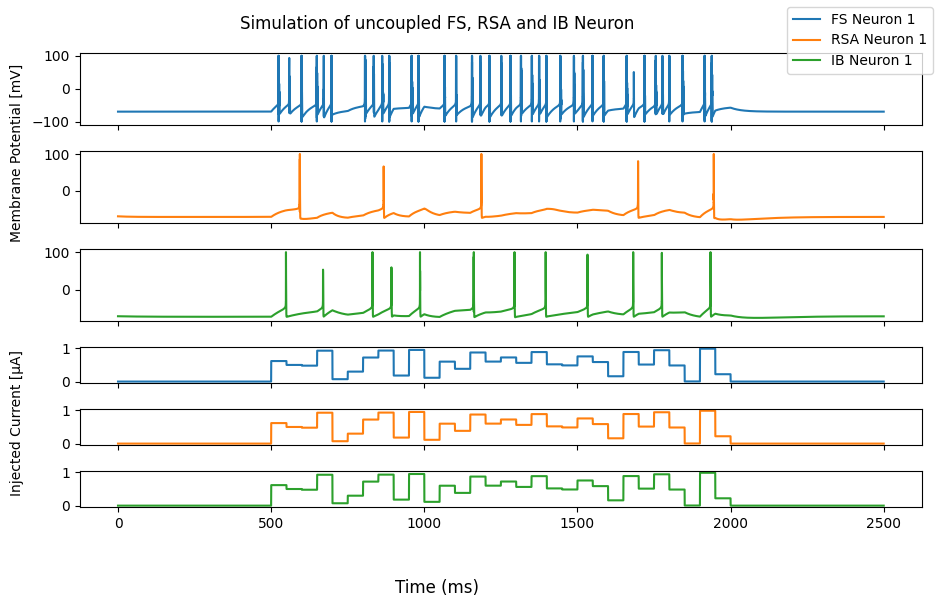

In [10]:
V_hist = np.array(uncoupled_model.V_history)

fig, axes = plt.subplots(
    2 * N,
    1,
    sharex=True,
    figsize=(10, 2 * N),
    gridspec_kw={"height_ratios": [2] * N + [1] * N}
)

colors = plt.cm.tab10.colors

all_handles = []
all_labels = []

for i in range(N):
    create_plot_materials(i, N, N_FS, N_RSA, axes, colors, times, V_hist, I_ext, all_handles, all_labels)

fig.text(0.08, 0.75, "Membrane Potential [mV]", va="center", ha="center", rotation="vertical")
fig.text(0.08, 0.30, "Injected Current [µA]", va="center", ha="center", rotation="vertical")
fig.supxlabel("Time (ms)")
fig.legend(all_handles, all_labels, loc="upper right")
fig.suptitle("Simulation of uncoupled FS, RSA and IB Neuron")

plt.tight_layout(rect=[0.08, 0.04, 1, 1])
plt.show()

## 2. Feedforward Excitation
We use 2 RSA neurons coupled with an electrical synapse($\epsilon_{21}^{el} = 0.1 mS$) and only the first neuron receiving external input current.

In [11]:
N_FS = 0                    # number of FS neurons
N_RSA = 2                   # number of RSA neurons
N_IB = 0                    # number of IB neurons
N = N_FS + N_RSA +  N_IB    # number of neurons in the network

# SEED for random injection current choices
SEED = 341

neuron_types = (
    ["FS"] * N_FS +
    ["RSA"] * N_RSA +
    ["IB"] * N_IB
)

C_M     = generate_simulation_params(NEURON_TYPE_PARAMS["C_M"], neuron_types)
g_bar_K = generate_simulation_params(NEURON_TYPE_PARAMS["g_bar_K"], neuron_types)
g_bar_M = generate_simulation_params(NEURON_TYPE_PARAMS["g_bar_M"], neuron_types)
g_bar_Ca= generate_simulation_params(NEURON_TYPE_PARAMS["g_bar_Ca"], neuron_types)
g_bar_Na= generate_simulation_params(NEURON_TYPE_PARAMS["g_bar_Na"], neuron_types)
g_L     = generate_simulation_params(NEURON_TYPE_PARAMS["g_L"], neuron_types)

tau_max = generate_simulation_params(NEURON_TYPE_PARAMS["tau_max"], neuron_types)

V_K     = generate_simulation_params(NEURON_TYPE_PARAMS["V_K"], neuron_types)
V_Ca    = generate_simulation_params(NEURON_TYPE_PARAMS["V_Ca"], neuron_types)
V_Na    = generate_simulation_params(NEURON_TYPE_PARAMS["V_Na"], neuron_types)
V_L     = generate_simulation_params(NEURON_TYPE_PARAMS["V_L"], neuron_types)
V_T     = generate_simulation_params(NEURON_TYPE_PARAMS["V_T"], neuron_types)

tau_r   = generate_simulation_params(NEURON_TYPE_PARAMS["tau_r"], neuron_types)
tau_d   = generate_simulation_params(NEURON_TYPE_PARAMS["tau_d"], neuron_types)
V_syn   = generate_simulation_params(NEURON_TYPE_PARAMS["V_syn"], neuron_types)
V_0     = generate_simulation_params(NEURON_TYPE_PARAMS["V_0"], neuron_types)

# Adjacency matrices describing the electrical synapses
A_el = np.array([
    [0, 0],
    [0.1, 0]
])
degrees_el = np.sum(A_el, axis=1)
D_el = np.diag(degrees_el)
L_el = D_el - A_el

# Chemical synapses allow for self-loops
A_ch = np.zeros((N, N))
degrees_ch = np.sum(A_ch, axis=1)
D_ch = np.diag(degrees_ch)
L_ch = D_ch - A_ch

# Selection vector to determine which neurons receive external current
S = np.array([[1], [0]])

# Time parameters
dt = 0.5                # Time step size
total_time = 2500.0     # Total Time to run the experiment for (ms)
times = np.arange(0.0, total_time + dt, dt)
cur_start_time = 500.0
cur_stop_time = 2000.0

# Injected Current
block_time = 50.0
I_inj = injection_current(seed=SEED, times=times, start=cur_start_time, stop=cur_stop_time, max_amplitude=1, block_time=block_time)

# External Current
I_ext = S * I_inj

V_init = V_L.copy()

# Steady state initial concentrations for the gates
alpha_n, beta_n = get_rates("n", V_init, V_T)
n_init =  alpha_n / (alpha_n + beta_n)

alpha_m, beta_m = get_rates("m", V_init, V_T)
m_init = alpha_m / (alpha_m + beta_m)

alpha_h, beta_h = get_rates("h", V_init, V_T)
h_init = alpha_h / (alpha_h + beta_h)

p_init = get_p_inf(V_init)

alpha_q, beta_q = get_rates("q", V_init, V_T)
q_init = alpha_q / (alpha_q + beta_q)

alpha_s, beta_s = get_rates("s", V_init, V_T)
s_init = alpha_s / (alpha_s + beta_s)

r_init = np.zeros((N, 1))

feedforward_model = HeterogeneousHH(
    N, C_M, g_bar_K, g_bar_M, g_bar_Ca, g_bar_Na, g_L,
    V_K, V_Ca, V_Na, V_L, V_T, V_syn,
    tau_max, tau_r, tau_d, V_0,
    L_el, A_ch,
    V_init, n_init, m_init, h_init,
    p_init, q_init, s_init, r_init,
)

feedforward_model.run_simulation(dt, I_ext)

  0%|          | 0/5000 [00:00<?, ?it/s]

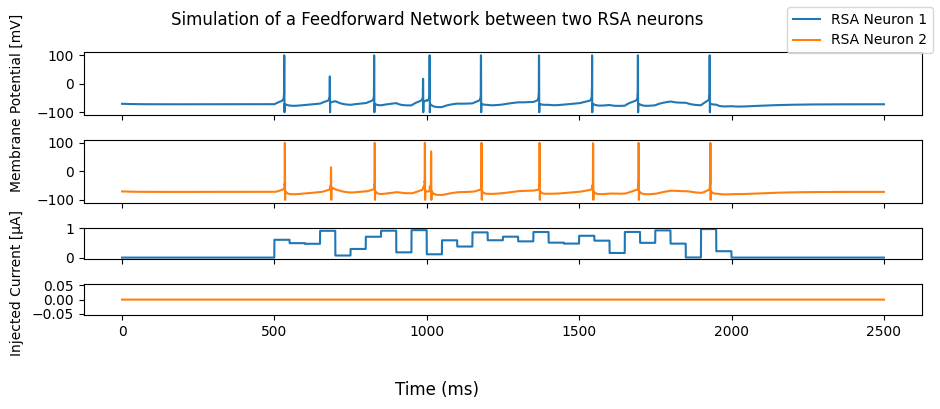

In [12]:
V_hist = np.array(feedforward_model.V_history)

fig, axes = plt.subplots(
    2 * N,
    1,
    sharex=True,
    figsize=(10, 2 * N),
    gridspec_kw={"height_ratios": [2] * N + [1] * N}
)

colors = plt.cm.tab10.colors

all_handles = []
all_labels = []

for i in range(N):
    create_plot_materials(i, N, N_FS, N_RSA, axes, colors, times, V_hist, I_ext, all_handles, all_labels)

fig.text(0.08, 0.75, "Membrane Potential [mV]", va="center", ha="center", rotation="vertical")
fig.text(0.08, 0.30, "Injected Current [µA]", va="center", ha="center", rotation="vertical")
fig.supxlabel("Time (ms)")
fig.legend(all_handles, all_labels, loc="upper right")
fig.suptitle("Simulation of a Feedforward Network between two RSA neurons")

plt.tight_layout(rect=[0.08, 0.04, 1, 1])
plt.show()


## 3. Feedback Excitation
We use the same set up from Part 2 (2 RSA neurons coupled with an electrical synapse ($\epsilon_{21}^{el} = 0.1 mS$) and only the first neuron receiving external input current), now with ad added feedback using a chemical synapse from neuron 2 to neuron 1 ($\epsilon_{12}^{ch} = 0.5$). 

In [13]:
N_FS = 0                    # number of FS neurons
N_RSA = 2                   # number of RSA neurons
N_IB = 0                    # number of IB neurons
N = N_FS + N_RSA +  N_IB    # number of neurons in the network

# SEED for random injection current choices
SEED = 341

neuron_types = (
    ["FS"] * N_FS +
    ["RSA"] * N_RSA +
    ["IB"] * N_IB
)

C_M     = generate_simulation_params(NEURON_TYPE_PARAMS["C_M"], neuron_types)
g_bar_K = generate_simulation_params(NEURON_TYPE_PARAMS["g_bar_K"], neuron_types)
g_bar_M = generate_simulation_params(NEURON_TYPE_PARAMS["g_bar_M"], neuron_types)
g_bar_Ca= generate_simulation_params(NEURON_TYPE_PARAMS["g_bar_Ca"], neuron_types)
g_bar_Na= generate_simulation_params(NEURON_TYPE_PARAMS["g_bar_Na"], neuron_types)
g_L     = generate_simulation_params(NEURON_TYPE_PARAMS["g_L"], neuron_types)

tau_max = generate_simulation_params(NEURON_TYPE_PARAMS["tau_max"], neuron_types)

V_K     = generate_simulation_params(NEURON_TYPE_PARAMS["V_K"], neuron_types)
V_Ca    = generate_simulation_params(NEURON_TYPE_PARAMS["V_Ca"], neuron_types)
V_Na    = generate_simulation_params(NEURON_TYPE_PARAMS["V_Na"], neuron_types)
V_L     = generate_simulation_params(NEURON_TYPE_PARAMS["V_L"], neuron_types)
V_T     = generate_simulation_params(NEURON_TYPE_PARAMS["V_T"], neuron_types)

tau_r   = generate_simulation_params(NEURON_TYPE_PARAMS["tau_r"], neuron_types)
tau_d   = generate_simulation_params(NEURON_TYPE_PARAMS["tau_d"], neuron_types)
V_syn   = generate_simulation_params(NEURON_TYPE_PARAMS["V_syn"], neuron_types)
V_0     = generate_simulation_params(NEURON_TYPE_PARAMS["V_0"], neuron_types)

# Adjacency matrices describing the electrical synapses
A_el = np.array([
    [0, 0],
    [0.1, 0]
])
degrees_el = np.sum(A_el, axis=1)
D_el = np.diag(degrees_el)
L_el = D_el - A_el

# Chemical synapses allow for self-loops
A_ch = np.array([
    [0, 0.5],
    [0, 0]
])
degrees_ch = np.sum(A_ch, axis=1)
D_ch = np.diag(degrees_ch)
L_ch = D_ch - A_ch

# Selection vector to determine which neurons receive external current
S = np.array([[1], [0]])

# Time parameters
dt = 0.3               # Time step size
total_time = 2500.0     # Total Time to run the experiment for (ms)
times = np.arange(0.0, total_time + dt, dt)
cur_start_time = 500.0
cur_stop_time = 2000.0

# Injected Current
block_time = 50.0
I_inj = injection_current(seed=SEED, times=times, start=cur_start_time, stop=cur_stop_time, max_amplitude=1, block_time=block_time)

# External Current
I_ext = S * I_inj

V_init = V_L.copy()

# Steady state initial concentrations for the gates
alpha_n, beta_n = get_rates("n", V_init, V_T)
n_init =  alpha_n / (alpha_n + beta_n)

alpha_m, beta_m = get_rates("m", V_init, V_T)
m_init = alpha_m / (alpha_m + beta_m)

alpha_h, beta_h = get_rates("h", V_init, V_T)
h_init = alpha_h / (alpha_h + beta_h)

p_init = get_p_inf(V_init)

alpha_q, beta_q = get_rates("q", V_init, V_T)
q_init = alpha_q / (alpha_q + beta_q)

alpha_s, beta_s = get_rates("s", V_init, V_T)
s_init = alpha_s / (alpha_s + beta_s)

r_init = np.zeros((N, 1))

feedback_model = HeterogeneousHH(
    N, C_M, g_bar_K, g_bar_M, g_bar_Ca, g_bar_Na, g_L,
    V_K, V_Ca, V_Na, V_L, V_T, V_syn,
    tau_max, tau_r, tau_d, V_0,
    L_el, A_ch,
    V_init, n_init, m_init, h_init,
    p_init, q_init, s_init, r_init,
)

feedback_model.run_simulation(dt, I_ext)

  0%|          | 0/8334 [00:00<?, ?it/s]

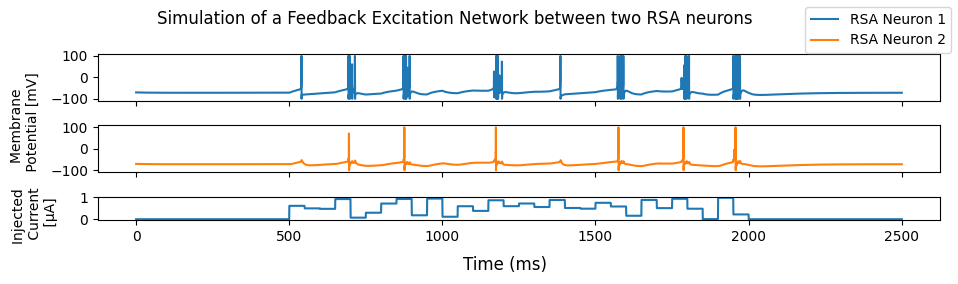

In [27]:
V_hist = np.array(feedback_model.V_history)

fig, axes = plt.subplots(
    N + 1,
    1,
    sharex=True,
    figsize=(10, N + 1),
    gridspec_kw={"height_ratios": [2] * N + [1]}
)

colors = plt.cm.tab10.colors

all_handles = []
all_labels = []

for i in range(N):
    # Remove constant currents
    if i > 0:
            create_plot_materials(i, N, N_FS, N_RSA, axes, colors, times, V_hist, I_ext, all_handles, all_labels, True)
    else:
        create_plot_materials(i, N, N_FS, N_RSA, axes, colors, times, V_hist, I_ext, all_handles, all_labels, False)

fig.text(0.07, 0.6, "Membrane \n Potential [mV]", va="center", ha="center", rotation="vertical")
fig.text(0.08, 0.3, "Injected \n Current \n [µA]", va="center", ha="center", rotation="vertical")
fig.supxlabel("Time (ms)", x=0.55, y=0.1, ha="center")
fig.legend(all_handles, all_labels, loc="upper right")
fig.suptitle("Simulation of a Feedback Excitation Network between two RSA neurons")

plt.tight_layout(rect=[0.08, 0.04, 1, 1])
plt.show()
